# Comparison of the heat budgets of CESM2-LENS Blob-analogs with The Blob in CESM FOSI

# 0. Set up

### 0.1 Import statements

In [1]:
import cmocean
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import dask
import matplotlib.pyplot as plt
import os
import xesmf as xe
import pop_tools

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter
from cartopy.util import add_cyclic_point
import matplotlib
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.animation import FFMpegWriter as fw
from matplotlib.animation import PillowWriter as pw
import json 
from IPython.utils import io
from os.path import exists
from scipy.stats import gaussian_kde
import seaborn as sns
import netCDF4 as nc4

In [2]:
import analysis_functions as funcs

### 0.2 Functions

In [3]:
def regrid_SMYLE(ds, glat=1, glon=1): # from Jacob's notebook
    """
    Inputs:
        ds: xr.DataArray with coordinates that include TLAT and TLONG
    Returns:
        Regridded xr.DataArray with coordinates lat and lon
    """
    ds = ds.rename(({'TLONG': 'lon', 'TLAT': 'lat'}))
    ds_out = xe.util.grid_global(glon, glat)
    regridder = xe.Regridder(ds, ds_out, 'bilinear', periodic=True)
    regridded = regridder(ds)
    new_coords = regridded.assign_coords({'y': regridded.lat[:, 0].values, 'x': regridded.lon[0].values})
    return new_coords.drop_vars(['lat', 'lon']).rename({'x': 'lon', 'y': 'lat'})

## FOSI 

In [17]:
# MHWs in FOSI
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc').labels # no trend

In [18]:
object_id = 94. # for 2
blobs = fosi_blobs
object_count_per_time = (blobs == object_id).sum(dim=['lat', 'lon'])
true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
# print(len(true_time_steps))
# print(true_time_steps)
# only_ts = regridded_ssta_no_trend_NEP.sel(time=true_time_steps.time)
one_obj = blobs.sel(time=true_time_steps.time)
blobs_nan = xr.where(one_obj == object_id, 1., 0.)

## 1. Loading data

In [4]:
# filepaths = [f'/glade/u/home/cmendiola/mhw_project/all_data_mhwobj_ssta/data_noseas/ens_{i}_mhwobj_rad2_noseas.nc' for i in range(100)]
# da_mhw = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
# da_mhwobj_labels = da_mhw.labels.compute()

# filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_mhwobj.nc' for i in range(100)]
# da_mhw = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
# da_mhwobj_labels = da_mhw.labels.sel(radius = 1).compute()

# filepaths = [f'/glade/work/cmendiola/data_ens_mean/ens_{i}_mhwobj.nc' for i in range(100)]
# da_mhw = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
# da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).compute()

# # filepaths = [f'/glade/work/cmendiola/data_quad_trend/ens_{i}_mhwobj.nc' for i in range(100)]
# da_mhw = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
# da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).compute()

In [4]:
file_path = 'object_id_ls_greenmask_linearr2.json'
with open(file_path, 'r') as file:
    blob_like_ids = json.load(file)

In [12]:
linr2_data[4]

100

In [ ]:
# ############ PREVIOUS METHOD
# # # With trend
# # filepaths = [f'/glade/u/home/cmendiola/mhw_project/data/ens_{i}_ssta_withtrend.nc' for i in range(100)]
# # da_ssta_withtrend = xr.open_mfdataset(filepaths, 
# #                                       combine='nested', 
# #                                       concat_dim='ensemble_member')

# # filepaths = [f'/glade/u/home/cmendiola/mhw_project/data/ens_{i}_mhwobj_rad3_withtrend.nc' for i in range(100)]
# # da_mhwobj = xr.open_mfdataset(filepaths, 
# #                               combine='nested', 
# #                               concat_dim='ensemble_member')
# # da_mhwobj_labels_withtrend = da_mhwobj.labels.compute()

# # No trend
# filepaths = [f'/glade/u/home/cmendiola/mhw_project/data/ens_{i}_ssta_notrend.nc' for i in range(100)]
# da_ssta = xr.open_mfdataset(filepaths, 
#                             combine='nested', 
#                             concat_dim='ensemble_member')

# filepaths = [f'/glade/u/home/cmendiola/mhw_project/data/ens_{i}_mhwobj_rad3.nc' for i in range(100)]
# da_mhwobj = xr.open_mfdataset(filepaths, 
#                               combine='nested', 
#                               concat_dim='ensemble_member')
# da_mhwobj_labels = da_mhwobj.labels.compute()

# # MHW IDs of Blob-analogs (50 percent overlap and greater is blob_like_ids[4]
# #blob_like_ids = json.load(open('object_id_ls_greenmask.json'))

In [5]:
#### CESM LENS2 for GRIDDING PURPOSES
var = 'SST'
comp = 'atm'
directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'
ens_memb_index = 0
ds_var_hist_SST, ds_var_fut_SST = funcs.get_ds_var(directory, 'SST','atm', ens_memb_index) 

# selecting our observational time period overlap with ERA5 (1979 to 2022)
CESMLENS_SST_hist_time_slice = ds_var_hist_SST.SST.sel(time=slice('1979-01-01', '2015-01-01'))
    
CESMLENS_SST_fut_time_slice = ds_var_fut_SST.SST.sel(time=slice('2015-02-01', '2020-12-01'))

CESMLENS_SST_ds = xr.concat([CESMLENS_SST_hist_time_slice, CESMLENS_SST_fut_time_slice], dim='time')
CESMLENS_SST = CESMLENS_SST_ds.compute()

# 2. The Blob in FOSI

In [67]:
#### FOSI
firstyear = 1979
lastyear = 2020
field = 'TEMP'

# Mask the Arctic, the Baltic Sea, the Red Sea, and the Black Sea
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)

fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
ds_smyle_fosi = xr.open_dataset(fpath+fname)[field].isel(z_t=0)

fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]
ds_smyle_fosi['time'] = fosi_montime_vals
fosi_temp = ds_smyle_fosi[ds_smyle_fosi.time['time.year'].isin(list(range(firstyear, lastyear+1)))].where(mask==1, np.nan)

fosi_anom_1deg_wzeros = funcs.regrid_SMYLE(ds_smyle_fosi)
fosi_anom_1deg = fosi_anom_1deg_wzeros.where(fosi_anom_1deg_wzeros!=0, np.nan)

regridder = xe.Regridder(fosi_anom_1deg.sel(time=slice('1979-01-01','2020-12-01')), CESMLENS_SST[:,:,:], 'nearest_s2d', periodic=True)
regridded = regridder(fosi_anom_1deg.sel(time=slice('1979-01-01','2020-12-01')))

In [ ]:
mean, trend, seas, features_notrend, ssta_notrend = funcs.calculate_anomalies_trend_features(regridded)

In [ ]:
upper_lat = 65
lower_lat = 5
left_lon = 150
right_lon = 250

mask_1deg = ~np.isnan(regridded.isel(time=0))
regridded_features_no_trend_NEP = features_notrend.sel(lon=slice(left_lon, right_lon), lat=slice(lower_lat,upper_lat))
regridded_ssta_no_trend_NEP = ssta_notrend.sel(lon=slice(left_lon, right_lon), lat=slice(lower_lat,upper_lat))
mask_1deg_NEP = mask_1deg.sel(lon=slice(left_lon, right_lon), lat=slice(lower_lat,upper_lat))

In [ ]:
mask_mask_3 = mask_3.sel(lon=slice(left_lon, right_lon), lat=slice(lower_lat,upper_lat))

In [ ]:
object_id = 83. # 
object_count_per_time = (fosi_blobs == object_id).sum(dim=['lat', 'lon'])
true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
only_ts = regridded_ssta_no_trend_NEP.sel(time=true_time_steps.time)
one_obj = fosi_blobs.sel(time=true_time_steps.time)
the_blob = xr.where(one_obj == object_id, 1., 0.)

In [ ]:
blobs_nan = xr.where(the_blob == 0., 0., 1.)

In [ ]:
# FOSI The Blob - measures
the_blob_ssta = regridded_ssta_no_trend_NEP.sel(time=true_time_steps.time)*the_blob
the_blob_ssta_nan = xr.where(the_blob_ssta > 0, the_blob_ssta, np.nan)

the_blob_mean_per_timestep = the_blob_ssta_nan.mean(dim=('lat','lon'))
the_blob_max_per_timestep = the_blob_ssta_nan.max(dim=('lat','lon'))
the_blob_max_ssta = the_blob_ssta_nan.max()
the_blob_mean_ssta = the_blob_ssta_nan.mean()

the_blob_percentile_90th = the_blob_ssta_nan.quantile(0.9, dim='time')
the_blob_percentile_90th_timestep = the_blob_ssta_nan.quantile(0.9, dim=('lat','lon'))
the_blob_percentile_90th_one_val = the_blob_ssta_nan.quantile(0.9)
the_blob_duration = the_blob_ssta_nan.time.shape[0]

# 3. Comparing heat budget terms of Blob-analogs in LENS with those of The Blob in FOSI

In [6]:
ens_memb_index = 0

In [ ]:
new_combined_ls = []
mld_combined_ls = []

for mhw_ind in range(len(linr2_data[4][ens_memb_index])):
    mhw_ind_obj_id = linr2_data[4][ens_memb_index][mhw_ind]
    print(mhw_ind_obj_id)

    # get the MHW event
    blobs = da_mhwobj_labels.isel(ensemble_member = ens_memb_index)
    object_count_per_time = (blobs == mhw_ind_obj_id).sum(dim=['lat', 'lon'])
    true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
    
    one_obj = blobs.sel(time=true_time_steps.time)
    blobs_nan = xr.where(one_obj == mhw_ind_obj_id, 1., 0.)

### 3.0 Functions

In [7]:
def calculate_pop_grid_anomalies_trend_features(ds, pop_grid_ds=None):
    """
    Calculate SST anomalies, trends, and features using POP grid information.
    
    Parameters:
    -----------
    ds : xarray.Dataset or DataArray
        Input SST data (with time, z_t/nlat/nlon or similar dims)
    pop_grid_ds : xarray.Dataset, optional
        POP grid dataset containing TAREA, ULAT, ULON if needed
        
    Returns:
    --------
    tuple of xarray.DataArray:
        (mean, trend, seasonal_cycle, features, anomalies)
    """
    # Ensure we're working with a DataArray
    if isinstance(ds, xr.Dataset):
        var = ds[list(ds.data_vars)[0]]  # take first variable if Dataset
    else:
        var = ds
    
    # Handle POP grid coordinates if provided
    if pop_grid_ds is not None:
        # Rename coordinates to match POP grid if needed
        if 'nlat' in pop_grid_ds.dims and 'nlon' in pop_grid_ds.dims:
            sst = sst.rename({'lat': 'nlat_t', 'lon': 'nlon_t'})
        # Ensure coordinates align
        sst = sst.assign_coords({
            'nlat_t': pop_grid_ds.nlat,
            'nlon_t': pop_grid_ds.nlon
        })
    
    # Calculate decimal years for model
    dyr = var.time.dt.year + var.time.dt.month/12
    
    # Build our 6-coefficient model
    model_components = [
        np.ones(len(dyr)),                         # Mean
        dyr - np.mean(dyr),                        # Trend
        np.sin(2 * np.pi * dyr),                   # Annual sine
        np.cos(2 * np.pi * dyr),                   # Annual cosine
        np.sin(4 * np.pi * dyr),                   # Semi-annual sine
        np.cos(4 * np.pi * dyr)                    # Semi-annual cosine
    ]
    
    model = np.array(model_components)
    pmodel = np.linalg.pinv(model)  # Pseudo-inverse for least squares
    
    # Convert to xarray DataArrays with proper dimensions
    model_da = xr.DataArray(
        model.T, 
        dims=['time', 'coeff'],
        coords={'time': var.time, 'coeff': np.arange(6)}
    )
    
    pmodel_da = xr.DataArray(
        pmodel.T,
        dims=['coeff', 'time'],
        coords={'coeff': np.arange(6), 'time': var.time}
    )
    
    # Calculate model coefficients
    var_mod = xr.DataArray(
        pmodel_da.dot(var),
        dims=['coeff', 'nlat_t', 'nlon_t'],
        coords={'coeff': np.arange(6), 'nlat_t': var.nlat_t, 'nlon_t': var.nlon_t}
    )
    
    # Construct components
    mean = model_da[:, 0].dot(var_mod[0, :, :])
    trend = model_da[:, 1].dot(var_mod[1, :, :])
    seasonal = model_da[:, 2:].dot(var_mod[2:, :, :])
    
    # Calculate anomalies by removing all model components
    var_notrend = var - model_da.dot(var_mod)
        
    return mean, trend, seasonal, var_notrend

In [8]:
def auto_scaled_kde(data, x_range=(-2, 2), nbins=15):
    """Automatically scales KDE to percentage with proper bin width."""
    # Calculate bin width
    data_range = x_range[1] - x_range[0]
    bin_width = data_range / nbins
    
    # Create KDE
    kde = gaussian_kde(data)
    x = np.linspace(x_range[0], x_range[1], 500)
    y = kde(x) * bin_width * 100  # Correct percentage scaling
    
    return x, y

In [9]:
def plot_tend_temp_segments(TEND_TEMP_result, values, xlim=(-2, 2), ylim=(0, 100), figsize=(10, 2), color = 'cyan'):
    # Validate input shape
    if TEND_TEMP_result.shape[1] != 4:
        raise ValueError("Input array must have 4 columns: [first3, middle1, middle2, last3]")
    
    colors = [color, color, color, color]
    titles = [
        'Pre-MHW', 
        'First Half of MHW', 
        'Second Half of MHW', 
        'Post-MHW'
    ]
    
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    axes = axes.ravel()

    for i in range(4):
        data = TEND_TEMP_result[:, i][~np.isnan(TEND_TEMP_result[:, i])]
        
        # if len(data) == 0:
        #     print(f"Warning: No valid data for segment {i+1}")
        #     continue
            
        # # Calculate KDE and convert to percentage
        # kde = gaussian_kde(data)
        # x = np.linspace(*xlim, 500)
        # y_percent = kde(x) * 100
        x, y_percent = auto_scaled_kde(data)
        
        # Plotting code remains the same...
        axes[i].plot(x, y_percent, color=colors[i], linewidth=2, alpha=0.9)
        
        # --- Styling ---
        axes[i].set_xlim(-2, 2)
        axes[i].set_ylim(0, 30)  # Set y-axis to percentage scale (0-100%)
        axes[i].set_title(titles[i], fontsize=12, pad=10)
        # axes[i].set_xlabel('°C/month', fontsize=11)
        # axes[i].set_ylabel('Percentage (%)', fontsize=11)  # Changed from 'Density'
        axes[i].set_facecolor('white')
        
        # Add grid lines
        axes[i].grid(True, linestyle='--', alpha=0.3)
        # Add annotation
        median_val = np.median(data)
        axes[i].axvline(values[i], color='k', linestyle='--', linewidth=1)
        axes[i].text(values[i], axes[i].get_ylim()[1]*0.9,
                    f'{values[i]:.2f}',
                    ha='center',
                    va='center',
                    fontsize=10,
                    bbox=dict(facecolor='white',
                             edgecolor='k',
                             boxstyle='round,pad=0.3',
                             alpha=0.8))

        pct_above = (data >  values[i]).mean() * 100
        mask = x >= values[i]
        axes[i].fill_between(x[mask], y_percent[mask], color=color, alpha=0.3, label=f'{pct_above:.1f}%')
        axes[i].text(1.3, axes[i].get_ylim()[1]*0.6,
                    f'{pct_above:.1f}%',
                    ha='center',
                    va='center',
                    fontsize=10,
                    bbox=dict(facecolor='white',
                             edgecolor='white',
                             alpha=0.8))
        
        axes[i].axvline(median_val, color='red', linestyle='--', linewidth=1)
        axes[i].axvline(x=0, color='grey', alpha=0.5, linewidth=1)
        axes[i].text(median_val, axes[i].get_ylim()[1]*0.1,
                    f'{median_val:.2f}',
                    ha='center',
                    va='center',
                    fontsize=10,
                    bbox=dict(facecolor='white',
                             edgecolor='red',
                             boxstyle='round,pad=0.3',
                             alpha=0.8))
    
        for spine in axes[i].spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('k')
            spine.set_linewidth(0.7)
        plt.tight_layout()
    return fig

In [10]:
def process_arrays(arr, peak_time):
    if len(arr) > 0 and len(arr) > 6 and peak_time < len(arr):
        pre = np.mean(arr[:3])
        post = np.mean(arr[-3:])
        core = arr[3:len(arr)-3]
        peak = arr[peak_time]
        if peak_time > 0:
            onset = np.mean(arr[3:peak_time+3])
        else:
            onset = np.nan
        decline = np.mean(arr[peak_time+3:len(arr)-3])
    else:
        pre = np.nan
        onset = np.nan
        peak = np.nan
        decline = np.nan
        post= np.nan
    return np.asarray([pre, onset, peak, decline, post])

### 3.1 Analysis

In [25]:
NO_SEC_IN_1_MON = 2629740

lat_slice=slice(204, 367)
lon_slice=slice(190, 280)

In [26]:
mean_image_pop_files = [f'/glade/derecho/scratch/cassiacai/mean_image_{i}_POP.nc' for i in range(1, 8)]
mean_images_pop = [xr.open_dataset(file) for file in mean_image_pop_files]
masks_pop = [xr.where(image.__xarray_dataarray_variable__ > 0.1, 1, 0) for image in mean_images_pop]
NEPac_MHW_renamed_latlon = NEPac_MHW = masks_pop[2][lat_slice, lon_slice].rename({'nlat': 'nlat_t', 'nlon': 'nlon_t'})

In [13]:
file_path = 'object_id_ls_greenmask_linearr2.json'
with open(file_path, 'r') as file:
    linr2_data = json.load(file)

In [16]:
total_elements = sum(len(inner_list) for inner_list in linr2_data[4])


In [17]:
total_elements

407

In [52]:
mask_3 = xr.open_dataset('mean_mask_3.nc').mhw_obj
mask_3 = xr.where(mask_3 > 0.1, 1, 0)
# mhw_obj_mask = mask_3

In [41]:
smaller_region_mask = mask_3.sel(
    lat = slice(5, 65), lon=slice(150, 250))

NameError: name 'mask_3' is not defined

In [27]:
filepaths = [f'/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/heat_budget_{i}_05232025.nc' for i in range(100)]
heat_budget_terms = xr.open_mfdataset(filepaths, 
                                      combine='nested', 
                                      concat_dim='ensemble_member')

In [83]:
def get_values_in_right_form(data):
    post_values = [inner_list[2] 
                         for middle_list in data 
                         for inner_list in middle_list]
    pre_values = [inner_list[0] 
                         for middle_list in data 
                         for inner_list in middle_list]
    
    mid_values = [inner_list[1] 
                         for middle_list in data 
                         for inner_list in middle_list]
    return post_values, pre_values, mid_values

In [84]:
post_tt, pre_tt, mid_tt = get_values_in_right_form(all_tt_mean_ls_combined)
post_totadv, pre_totadv, mid_totadv = get_values_in_right_form(all_totadv_mean_ls_combined)
post_subgrid, pre_subgrid, mid_subgrid = get_values_in_right_form(all_subgrid_mean_ls_combined)
post_qsw, pre_qsw, mid_qsw = get_values_in_right_form(all_qsw_mean_ls_combined)
post_shf, pre_shf, mid_shf = get_values_in_right_form(all_shf_mean_ls_combined)


/glade/derecho/scratch/cassiacai/tmp/ipykernel_28054/1611097657.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
/glade/derecho/scratch/cassiacai/tmp/ipykernel_28054/1611097657.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
/glade/derecho/scratch/cassiacai/tmp/ipykernel_28054/1611097657.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
/glade/derecho/scratch/cassiacai/tmp/ipykernel_28054/1611097657.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will 

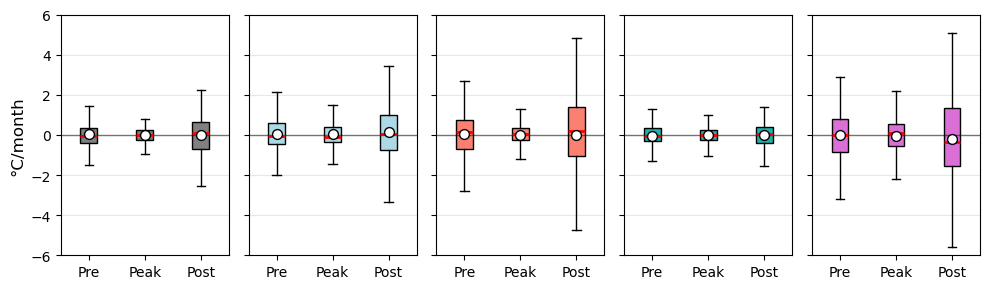

In [88]:
# Your current data format:
# post_tt, pre_tt, mid_tt = get_values_in_right_form(all_tt_mean_ls_combined)
# post_totadv, pre_totadv, mid_totadv = get_values_in_right_form(all_totadv_mean_ls_combined)
# ... etc.

# Convert to the format needed for boxplots
# Assuming each variable has 3 periods: pre, mid, post
# But your boxplot code expects 5 periods, so I'll show both options

# Option 1: If you want to keep 3 periods (Pre, Peak, Post)
variables = {
    'TEND_TEMP': {
        'data': np.column_stack([pre_tt, mid_tt, post_tt]),  # Combine into 2D array
        'values': [np.mean(pre_tt), np.mean(mid_tt), np.mean(post_tt)],  # Mean values for each period
        'color': 'grey'
    },
    'TOT_ADV': {
        'data': np.column_stack([pre_totadv, mid_totadv, post_totadv]),
        'values': [np.mean(pre_totadv), np.mean(mid_totadv), np.mean(post_totadv)],
        'color': 'lightblue'
    },
    'SHF_depth': {
        'data': np.column_stack([pre_shf, mid_shf, post_shf]),
        'values': [np.mean(pre_shf), np.mean(mid_shf), np.mean(post_shf)],
        'color': 'salmon'
    },
    'QSW_3D': {
        'data': np.column_stack([pre_qsw, mid_qsw, post_qsw]),
        'values': [np.mean(pre_qsw), np.mean(mid_qsw), np.mean(post_qsw)],
        'color': 'lightseagreen'
    },
    'SUBGRID': {
        'data': np.column_stack([pre_subgrid, mid_subgrid, post_subgrid]),
        'values': [np.mean(pre_subgrid), np.mean(mid_subgrid), np.mean(post_subgrid)],
        'color': 'orchid'
    }
}

time_periods = ["Pre", "Peak", "Post"]

# Create figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 3), sharey=True)

for ax, (var_name, var_data) in zip(axes, variables.items()):
    # Prepare data for all periods
    all_data = [var_data['data'][:, i][~np.isnan(var_data['data'][:, i])] for i in range(3)]
    
    # Create boxplot
    box = ax.boxplot(
        all_data,
        patch_artist=True,
        labels=time_periods,
        showfliers=False,
        medianprops={'color': 'red', 'linewidth': 2},
        positions=range(1, 4)  # Only 3 positions now
    )
    
    # Style boxes
    for patch in box['boxes']:
        patch.set_facecolor(var_data['color'])
    
    # Add dots for each period
    for i, (x_pos, value) in enumerate(zip(range(1, 4), var_data['values'])):
        ax.scatter(
            x_pos,
            value,
            color='white',
            edgecolor='k',
            s=50,
            zorder=10,
            label=f'Value: {value:.2f}°C/month' if i == 0 else ""
        )
    
    # Subplot customization
    ax.set_ylim(-6, 6)
    ax.axhline(y=0, c='k', linewidth=1, alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    if ax == axes[0]:
        ax.set_ylabel('°C/month', fontsize=12)

plt.tight_layout()
plt.show()

In [71]:
all_tt_mean_ls_combined = []
all_totadv_mean_ls_combined = []
all_subgrid_mean_ls_combined = []
all_qsw_mean_ls_combined = []
all_shf_mean_ls_combined = []

for ens_memb_index in range(0, 100):
    print('***', ens_memb_index,'***')
    heat_budget_terms_ds = heat_budget_terms.isel(ensemble_member = ens_memb_ind).compute()

    TEND_TEMP = heat_budget_terms.TEND_TEMP[ens_memb_ind].compute()
    TOT_ADV = heat_budget_terms.TOT_ADV[ens_memb_ind].compute()
    SHF_depth = heat_budget_terms.SHF_depth[ens_memb_ind].compute()
    QSW_3D = heat_budget_terms.QSW_3D[ens_memb_ind].compute()
    SUBGRID = TEND_TEMP - SHF_depth - TOT_ADV - QSW_3D
        
    TEND_TEMP_nan = xr.where(TEND_TEMP == 0., np.nan, TEND_TEMP)*NO_SEC_IN_1_MON
    TOT_ADV_nan = xr.where(TOT_ADV == 0., np.nan, TOT_ADV)*NO_SEC_IN_1_MON
    SHF_depth_nan = xr.where(SHF_depth == 0., np.nan, SHF_depth)*NO_SEC_IN_1_MON
    QSW_3D_nan = xr.where(QSW_3D == 0., np.nan, QSW_3D)*NO_SEC_IN_1_MON
    SUBGRID_nan = xr.where(SUBGRID == 0., np.nan, SUBGRID)*NO_SEC_IN_1_MON
        
    mean, trend, seasonal, TEND_TEMP_notrend = calculate_pop_grid_anomalies_trend_features(TEND_TEMP_nan)
    mean, trend, seasonal, TOT_ADV_notrend = calculate_pop_grid_anomalies_trend_features(TOT_ADV_nan)
    mean, trend, seasonal, SHF_depth_notrend = calculate_pop_grid_anomalies_trend_features(SHF_depth_nan)
    mean, trend, seasonal, QSW_3D_notrend = calculate_pop_grid_anomalies_trend_features(QSW_3D_nan)
    mean, trend, seasonal, SUBGRID_notrend = calculate_pop_grid_anomalies_trend_features(SUBGRID_nan)

    TEND_TEMP_notrend_smaller_reg = TEND_TEMP_notrend*NEPac_MHW_renamed_latlon
    TOT_ADV_notrend_smaller_reg = TOT_ADV_notrend*NEPac_MHW_renamed_latlon
    SHF_depth_notrend_smaller_reg = SHF_depth_notrend*NEPac_MHW_renamed_latlon
    QSW_3D_notrend_smaller_reg = QSW_3D_notrend*NEPac_MHW_renamed_latlon
    SUBGRID_notrend_smaller_reg = SUBGRID_notrend*NEPac_MHW_renamed_latlon

    TEND_TEMP_notrend_smaller_reg_nan = xr.where(TEND_TEMP_notrend_smaller_reg == 0., np.nan, TEND_TEMP_notrend_smaller_reg)
    TOT_ADV_notrend_smaller_reg_nan = xr.where(TOT_ADV_notrend_smaller_reg == 0., np.nan, TOT_ADV_notrend_smaller_reg)
    SHF_depth_notrend_smaller_reg_nan = xr.where(SHF_depth_notrend_smaller_reg == 0., np.nan, SHF_depth_notrend_smaller_reg)
    QSW_3D_notrend_smaller_reg_nan = xr.where(QSW_3D_notrend_smaller_reg == 0., np.nan, QSW_3D_notrend_smaller_reg)
    SUBGRID_notrend_smaller_reg_nan = xr.where(SUBGRID_notrend_smaller_reg == 0., np.nan, SUBGRID_notrend_smaller_reg)

    all_tt_mean_ls = []
    all_totadv_mean_ls = []
    all_subgrid_mean_ls = []
    all_qsw_mean_ls = []
    all_shf_mean_ls = []
    
    for mhw_ind in range(len(linr2_data[4][ens_memb_index])):
        mhw_ind_obj_id = linr2_data[4][ens_memb_index][mhw_ind]
        # get the MHW event
        blobs = da_mhwobj_labels.isel(ensemble_member = ens_memb_index)
        object_count_per_time = (blobs == mhw_ind_obj_id).sum(dim=['lat', 'lon'])
        true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
            
        one_obj = blobs.sel(time=true_time_steps.time)
        blobs_nan = xr.where(one_obj == mhw_ind_obj_id, 1., 0.)
    
        temptenda = calc_anom_heat_budget_distrib(blobs_nan, TEND_TEMP_notrend_smaller_reg_nan)
        totadva = calc_anom_heat_budget_distrib(blobs_nan, TOT_ADV_notrend_smaller_reg_nan)
        subgrida = calc_anom_heat_budget_distrib(blobs_nan, SUBGRID_notrend_smaller_reg_nan)
        qswa = calc_anom_heat_budget_distrib(blobs_nan, QSW_3D_notrend_smaller_reg_nan)
        shfa = calc_anom_heat_budget_distrib(blobs_nan, SHF_depth_notrend_smaller_reg_nan)
    
        ttend_mean_ls, ttend_std_ls = calc_phase_mean_std(temptenda)
        totadv_mean_ls, totadv_std_ls = calc_phase_mean_std(totadva)
        subgrid_mean_ls, subgrid_std_ls = calc_phase_mean_std(subgrida)
        qsw_mean_ls, qsw_std_ls = calc_phase_mean_std(qswa)
        shf_mean_ls, shf_std_ls = calc_phase_mean_std(shfa)
    
        all_tt_mean_ls.append(ttend_mean_ls)
        all_totadv_mean_ls.append(totadv_mean_ls)
        all_subgrid_mean_ls.append(subgrid_mean_ls)
        all_qsw_mean_ls.append(qsw_mean_ls)
        all_shf_mean_ls.append(shf_mean_ls)

    all_tt_mean_ls_combined.append(all_tt_mean_ls)
    all_totadv_mean_ls_combined.append(all_totadv_mean_ls)
    all_subgrid_mean_ls_combined.append(all_subgrid_mean_ls)
    all_qsw_mean_ls_combined.append(all_qsw_mean_ls)
    all_shf_mean_ls_combined.append(all_shf_mean_ls)

*** 0 ***
*** 1 ***
*** 2 ***
*** 3 ***
*** 4 ***
*** 5 ***
*** 6 ***
*** 7 ***
*** 8 ***
*** 9 ***
*** 10 ***
*** 11 ***
*** 12 ***
*** 13 ***
*** 14 ***
*** 15 ***
*** 16 ***
*** 17 ***
*** 18 ***
*** 19 ***
*** 20 ***
*** 21 ***
*** 22 ***
*** 23 ***
*** 24 ***
*** 25 ***
*** 26 ***
*** 27 ***
*** 28 ***
*** 29 ***
*** 30 ***
*** 31 ***
*** 32 ***
*** 33 ***
*** 34 ***
*** 35 ***
*** 36 ***
*** 37 ***
*** 38 ***
*** 39 ***
*** 40 ***
*** 41 ***
*** 42 ***
*** 43 ***
*** 44 ***
*** 45 ***
*** 46 ***
*** 47 ***
*** 48 ***
*** 49 ***
*** 50 ***
*** 51 ***
*** 52 ***
*** 53 ***
*** 54 ***
*** 55 ***
*** 56 ***
*** 57 ***
*** 58 ***
*** 59 ***
*** 60 ***
*** 61 ***
*** 62 ***
*** 63 ***
*** 64 ***
*** 65 ***
*** 66 ***
*** 67 ***
*** 68 ***
*** 69 ***
*** 70 ***
*** 71 ***
*** 72 ***
*** 73 ***
*** 74 ***
*** 75 ***
*** 76 ***
*** 77 ***
*** 78 ***
*** 79 ***
*** 80 ***
*** 81 ***
*** 82 ***
*** 83 ***
*** 84 ***
*** 85 ***
*** 86 ***
*** 87 ***
*** 88 ***
*** 89 ***
*** 90 ***
*** 91 **

In [72]:
filename = '/glade/derecho/scratch/cassiacai/mhwp2_temp_tend_a_ens_0_100.json'
with open(filename, 'w') as f:
    json.dump(all_tt_mean_ls_combined, f)

filename = '/glade/derecho/scratch/cassiacai/mhwp2_totadv_a_ens_0_100.json'
with open(filename, 'w') as f:
    json.dump(all_totadv_mean_ls_combined, f)

filename = '/glade/derecho/scratch/cassiacai/mhwp2_subgrid_a_ens_0_100.json'
with open(filename, 'w') as f:
    json.dump(all_subgrid_mean_ls_combined, f)

filename = '/glade/derecho/scratch/cassiacai/mhwp2_qsw_a_ens_0_100.json'
with open(filename, 'w') as f:
    json.dump(all_qsw_mean_ls_combined, f)

filename = '/glade/derecho/scratch/cassiacai/mhwp2_shf_a_ens_0_100.json'
with open(filename, 'w') as f:
    json.dump(all_shf_mean_ls_combined, f)

In [28]:
ens_memb_ind = 0

In [29]:
heat_budget_terms_ds = heat_budget_terms.isel(ensemble_member = ens_memb_ind).compute()

In [31]:
filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).sel(time=slice('1979-01', '2020-12')).compute()

In [45]:
blob_footprint_heatbudget = heat_budget_terms_ds*NEPac_MHW_renamed_latlon

In [47]:
TEND_TEMP = heat_budget_terms.TEND_TEMP[ens_memb_ind].compute()
TOT_ADV = heat_budget_terms.TOT_ADV[ens_memb_ind].compute()
SHF_depth = heat_budget_terms.SHF_depth[ens_memb_ind].compute()
QSW_3D = heat_budget_terms.QSW_3D[ens_memb_ind].compute()
SUBGRID = TEND_TEMP - SHF_depth - TOT_ADV - QSW_3D
    
TEND_TEMP_nan = xr.where(TEND_TEMP == 0., np.nan, TEND_TEMP)*NO_SEC_IN_1_MON
TOT_ADV_nan = xr.where(TOT_ADV == 0., np.nan, TOT_ADV)*NO_SEC_IN_1_MON
SHF_depth_nan = xr.where(SHF_depth == 0., np.nan, SHF_depth)*NO_SEC_IN_1_MON
QSW_3D_nan = xr.where(QSW_3D == 0., np.nan, QSW_3D)*NO_SEC_IN_1_MON
SUBGRID_nan = xr.where(SUBGRID == 0., np.nan, SUBGRID)*NO_SEC_IN_1_MON
    
mean, trend, seasonal, TEND_TEMP_notrend = calculate_pop_grid_anomalies_trend_features(TEND_TEMP_nan)
mean, trend, seasonal, TOT_ADV_notrend = calculate_pop_grid_anomalies_trend_features(TOT_ADV_nan)
mean, trend, seasonal, SHF_depth_notrend = calculate_pop_grid_anomalies_trend_features(SHF_depth_nan)
mean, trend, seasonal, QSW_3D_notrend = calculate_pop_grid_anomalies_trend_features(QSW_3D_nan)
mean, trend, seasonal, SUBGRID_notrend = calculate_pop_grid_anomalies_trend_features(SUBGRID_nan)

In [48]:
TEND_TEMP_notrend_smaller_reg = TEND_TEMP_notrend*NEPac_MHW_renamed_latlon
TOT_ADV_notrend_smaller_reg = TOT_ADV_notrend*NEPac_MHW_renamed_latlon
SHF_depth_notrend_smaller_reg = SHF_depth_notrend*NEPac_MHW_renamed_latlon
QSW_3D_notrend_smaller_reg = QSW_3D_notrend*NEPac_MHW_renamed_latlon
SUBGRID_notrend_smaller_reg = SUBGRID_notrend*NEPac_MHW_renamed_latlon

In [49]:
TEND_TEMP_notrend_smaller_reg_nan = xr.where(TEND_TEMP_notrend_smaller_reg == 0., np.nan, TEND_TEMP_notrend_smaller_reg)
TOT_ADV_notrend_smaller_reg_nan = xr.where(TOT_ADV_notrend_smaller_reg == 0., np.nan, TOT_ADV_notrend_smaller_reg)
SHF_depth_notrend_smaller_reg_nan = xr.where(SHF_depth_notrend_smaller_reg == 0., np.nan, SHF_depth_notrend_smaller_reg)
QSW_3D_notrend_smaller_reg_nan = xr.where(QSW_3D_notrend_smaller_reg == 0., np.nan, QSW_3D_notrend_smaller_reg)
SUBGRID_notrend_smaller_reg_nan = xr.where(SUBGRID_notrend_smaller_reg == 0., np.nan, SUBGRID_notrend_smaller_reg)

In [67]:
def calc_anom_heat_budget_distrib(blobs_nan, ds):
    anom_ls = []
    for i in [-3, -2, -1]:
        time_index = 0
        tmin1_anomalies = ds.shift(time=i).sel(time=blobs_nan.time[time_index].item())
        anomalies_in_region_nan = xr.where(tmin1_anomalies == 0., np.nan, tmin1_anomalies)
        anom_ls.append(anomalies_in_region_nan.mean(dim=('nlat_t','nlon_t')).item())
        
    for time_index in range(len(blobs_nan.time)):
        anomalies_in_region = ds.sel(time=blobs_nan.time[time_index].item())
        anomalies_in_region_nan = xr.where(anomalies_in_region == 0., np.nan, anomalies_in_region)
        anom_ls.append(anomalies_in_region_nan.mean(dim=('nlat_t','nlon_t')).item())
            
    for i in [1, 2, 3]:
        time_index = len(blobs_nan.time)-1
        tmin1_anomalies = ds.shift(time=i).sel(time=blobs_nan.time[time_index].item())
        anomalies_in_region_nan = xr.where(tmin1_anomalies == 0., np.nan, tmin1_anomalies)
        anom_ls.append(anomalies_in_region_nan.mean(dim=('nlat_t','nlon_t')).item())

    return anom_ls

In [68]:
def calc_phase_mean_std(anom_ls):
    pre_mean = np.mean(np.asarray(anom_ls[:3]))
    mid_mean = np.mean(np.asarray(anom_ls[3:-3]))
    post_mean = np.mean(np.asarray(anom_ls[-3]))

    pre_std = np.std(np.asarray(anom_ls[:3]))
    mid_std = np.std(np.asarray(anom_ls[3:-3]))
    post_std = np.std(np.asarray(anom_ls[-3]))

    mean_ls = [pre_mean, mid_mean, post_mean]
    std_ls = [pre_std, mid_std, post_std]
    return mean_ls, std_ls

In [69]:
all_tt_mean_ls = []
all_totadv_mean_ls = []
all_subgrid_mean_ls = []
all_qsw_mean_ls = []
all_shf_mean_ls = []

for mhw_ind in range(len(linr2_data[4][ens_memb_index])):
    mhw_ind_obj_id = linr2_data[4][ens_memb_index][mhw_ind]
    # get the MHW event
    blobs = da_mhwobj_labels.isel(ensemble_member = ens_memb_index)
    object_count_per_time = (blobs == mhw_ind_obj_id).sum(dim=['lat', 'lon'])
    true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
        
    one_obj = blobs.sel(time=true_time_steps.time)
    blobs_nan = xr.where(one_obj == mhw_ind_obj_id, 1., 0.)

    temptenda = calc_anom_heat_budget_distrib(blobs_nan, TEND_TEMP_notrend_smaller_reg_nan)
    totadva = calc_anom_heat_budget_distrib(blobs_nan, TOT_ADV_notrend_smaller_reg_nan)
    subgrida = calc_anom_heat_budget_distrib(blobs_nan, SUBGRID_notrend_smaller_reg_nan)
    qswa = calc_anom_heat_budget_distrib(blobs_nan, QSW_3D_notrend_smaller_reg_nan)
    shfa = calc_anom_heat_budget_distrib(blobs_nan, SHF_depth_notrend_smaller_reg_nan)

    ttend_mean_ls, ttend_std_ls = calc_phase_mean_std(temptenda)
    totadv_mean_ls, totadv_std_ls = calc_phase_mean_std(totadva)
    subgrid_mean_ls, subgrid_std_ls = calc_phase_mean_std(subgrida)
    qsw_mean_ls, qsw_std_ls = calc_phase_mean_std(qswa)
    shf_mean_ls, shf_std_ls = calc_phase_mean_std(shfa)

    all_tt_mean_ls.append(ttend_mean_ls)
    all_totadv_mean_ls.append(totadv_mean_ls)
    all_subgrid_mean_ls.append(subgrid_mean_ls)
    all_qsw_mean_ls.append(qsw_mean_ls)
    all_shf_mean_ls.append(shf_mean_ls)

In [98]:
mhw_ind = 0
mhw_ind_obj_id = blob_like_ids[4][ens_memb_index][mhw_ind]
print(mhw_ind_obj_id)

# get the MHW event
blobs = da_mhwobj_labels.isel(ensemble_member = ens_memb_index)
object_count_per_time = (blobs == mhw_ind_obj_id).sum(dim=['lat', 'lon'])
true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
    
one_obj = blobs.sel(time=true_time_steps.time)
blobs_nan = xr.where(one_obj == mhw_ind_obj_id, 1., 0.)

28.0


In [ ]:
new_combined_ls = []
mld_combined_ls = []

for mhw_ind in range(len(linr2_data[4][ens_memb_index])):
    mhw_ind_obj_id = linr2_data[4][ens_memb_index][mhw_ind]
    print(mhw_ind_obj_id)

    # get the MHW event
    blobs = da_mhwobj_labels.isel(ensemble_member = ens_memb_index)
    object_count_per_time = (blobs == mhw_ind_obj_id).sum(dim=['lat', 'lon'])
    true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
    
    one_obj = blobs.sel(time=true_time_steps.time)
    blobs_nan = xr.where(one_obj == mhw_ind_obj_id, 1., 0.)

In [23]:
masked_TEND_TEMP_anom_nan_ls_full = []
masked_TOT_ADV_anom_nan_ls_full = []
masked_SHF_depth_anom_nan_ls_full = []
masked_QSW_3D_anom_nan_ls_full = []
masked_SUBGRID_anom_nan_ls_full = []

for ens_memb_ind in range(0, 100):
    print(ens_memb_ind)
    TEND_TEMP = heat_budget_terms.TEND_TEMP[ens_memb_ind].compute()
    TOT_ADV = heat_budget_terms.TOT_ADV[ens_memb_ind].compute()
    SHF_depth = heat_budget_terms.SHF_depth[ens_memb_ind].compute()
    QSW_3D = heat_budget_terms.QSW_3D[ens_memb_ind].compute()
    SUBGRID = TEND_TEMP - SHF_depth - TOT_ADV - QSW_3D
    
    TEND_TEMP_nan = xr.where(TEND_TEMP == 0., np.nan, TEND_TEMP)*NO_SEC_IN_1_MON
    TOT_ADV_nan = xr.where(TOT_ADV == 0., np.nan, TOT_ADV)*NO_SEC_IN_1_MON
    SHF_depth_nan = xr.where(SHF_depth == 0., np.nan, SHF_depth)*NO_SEC_IN_1_MON
    QSW_3D_nan = xr.where(QSW_3D == 0., np.nan, QSW_3D)*NO_SEC_IN_1_MON
    SUBGRID_nan = xr.where(SUBGRID == 0., np.nan, SUBGRID)*NO_SEC_IN_1_MON
    
    mean, trend, seasonal, TEND_TEMP_notrend = calculate_pop_grid_anomalies_trend_features(TEND_TEMP_nan)
    mean, trend, seasonal, TOT_ADV_notrend = calculate_pop_grid_anomalies_trend_features(TOT_ADV_nan)
    mean, trend, seasonal, SHF_depth_notrend = calculate_pop_grid_anomalies_trend_features(SHF_depth_nan)
    mean, trend, seasonal, QSW_3D_notrend = calculate_pop_grid_anomalies_trend_features(QSW_3D_nan)
    mean, trend, seasonal, SUBGRID_notrend = calculate_pop_grid_anomalies_trend_features(SUBGRID_nan)
    
    masked_TEND_TEMP_anom_nan_ls = []
    masked_TOT_ADV_anom_nan_ls = []
    masked_SHF_depth_anom_nan_ls = []
    masked_QSW_3D_anom_nan_ls = []
    masked_SUBGRID_anom_nan_ls = []

    for i in range(len(blob_like_ids[4][ens_memb_ind])):
        mhw_ind = blob_like_ids[4][ens_memb_ind][i]
        first_time = da_mhwobj_labels[ens_memb_ind,:,:,:].where(
            da_mhwobj_labels[ens_memb_ind,:,:,:] == mhw_ind, drop=True).time[0] - xr.coding.cftime_offsets.to_offset("3MS")
        last_time = da_mhwobj_labels[ens_memb_ind,:,:,:].where(
            da_mhwobj_labels[ens_memb_ind,:,:,:] == mhw_ind, drop=True).time[-1] + xr.coding.cftime_offsets.to_offset("3MS")
        
        ssta = da_ssta.__xarray_dataarray_variable__[ens_memb_ind].sel(time=slice(first_time, last_time))
    
        blob_region = ssta*smaller_region_mask
        blob_region_nan = xr.where(blob_region == 0., np.nan, blob_region)
        mean_ssta = blob_region_nan.mean(dim=('lat','lon')).compute()

        peak_time = mean_ssta.argmax().item()

        masked_TEND_TEMP_anom = TEND_TEMP_notrend.sel(time=slice(first_time, last_time))*NEPac_MHW_renamed_latlon
        masked_TEND_TEMP_anom_nan = xr.where(masked_TEND_TEMP_anom == 0., np.nan, masked_TEND_TEMP_anom).mean(dim=('nlat_t','nlon_t')).values
    
        # calculating the means
        # masked_TEND_TEMP_anom = TEND_TEMP_notrend.sel(time=slice(first_time, last_time))*NEPac_MHW_renamed_latlon
        # masked_TEND_TEMP_anom_nan = xr.where(masked_TEND_TEMP_anom == 0., np.nan, masked_TEND_TEMP_anom).mean(dim=('nlat_t','nlon_t')).values
        
        masked_TOT_ADV_anom = TOT_ADV_notrend.sel(time=slice(first_time, last_time))*NEPac_MHW_renamed_latlon
        masked_TOT_ADV_anom_nan = xr.where(masked_TOT_ADV_anom == 0., np.nan, masked_TOT_ADV_anom).mean(dim=('nlat_t','nlon_t')).values
        
        masked_SHF_depth_anom = SHF_depth_notrend.sel(time=slice(first_time, last_time))*NEPac_MHW_renamed_latlon
        masked_SHF_depth_anom_nan = xr.where(masked_SHF_depth_anom == 0., np.nan, masked_SHF_depth_anom).mean(dim=('nlat_t','nlon_t')).values
        
        masked_QSW_3D_anom = QSW_3D_notrend.sel(time=slice(first_time, last_time))*NEPac_MHW_renamed_latlon
        masked_QSW_3D_anom_nan = xr.where(masked_QSW_3D_anom == 0., np.nan, masked_QSW_3D_anom).mean(dim=('nlat_t','nlon_t')).values
        
        masked_SUBGRID_anom = SUBGRID_notrend.sel(time=slice(first_time, last_time))*NEPac_MHW_renamed_latlon
        masked_SUBGRID_anom_nan = xr.where(masked_SUBGRID_anom == 0., np.nan, masked_SUBGRID_anom).mean(dim=('nlat_t','nlon_t')).values
    
        masked_TEND_TEMP_anom_nan_ls.append(
            process_arrays(masked_TEND_TEMP_anom_nan, peak_time)
        )
        masked_TOT_ADV_anom_nan_ls.append(
            process_arrays(masked_TOT_ADV_anom_nan, peak_time)
        )
        masked_SHF_depth_anom_nan_ls.append(
            process_arrays(masked_SHF_depth_anom_nan, peak_time)
        )
        masked_QSW_3D_anom_nan_ls.append(
            process_arrays(masked_QSW_3D_anom_nan, peak_time)
        )
        masked_SUBGRID_anom_nan_ls.append(
            process_arrays(masked_SUBGRID_anom_nan, peak_time)
        )
    
    masked_TEND_TEMP_anom_nan_ls_full.append(masked_TEND_TEMP_anom_nan_ls)
    masked_TOT_ADV_anom_nan_ls_full.append(masked_TOT_ADV_anom_nan_ls)
    masked_SHF_depth_anom_nan_ls_full.append(masked_SHF_depth_anom_nan_ls)
    masked_QSW_3D_anom_nan_ls_full.append(masked_QSW_3D_anom_nan_ls)
    masked_SUBGRID_anom_nan_ls_full.append(masked_SUBGRID_anom_nan_ls)

0


/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


1


/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


2


...

/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


96
97
98


/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


99


/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [169]:
# ens_memb_ind = 0
# i = 0
# mhw_ind = blob_like_ids[4][ens_memb_ind][i]
# first_time = da_mhwobj_labels[ens_memb_ind,:,:,:].where(
#     da_mhwobj_labels[ens_memb_ind,:,:,:] == mhw_ind, drop=True).time[0] - xr.coding.cftime_offsets.to_offset("3MS")
# last_time = da_mhwobj_labels[ens_memb_ind,:,:,:].where(
#     da_mhwobj_labels[ens_memb_ind,:,:,:] == mhw_ind, drop=True).time[-1] + xr.coding.cftime_offsets.to_offset("3MS")

# ssta = da_ssta.__xarray_dataarray_variable__[ens_memb_ind].sel(
#     time=slice(first_time, last_time))

# blob_region = ssta*smaller_region_mask
# blob_region_nan = xr.where(blob_region == 0., np.nan, blob_region)
# mean_ssta = blob_region_nan.mean(dim=('lat','lon')).compute()
# mean_ssta = ssta.mean(dim=('lat','lon'))[3:len(arr)-3].compute()
# pre = np.mean(arr[:3])
# post = np.mean(arr[-3:])
# core = arr[3:len(arr)-3]
# peak_time = mean_ssta.argmax().item()
# peak = arr[peak_time]
# if peak_time > 0:
#     onset = np.mean(arr[3:peak_time+3])
# else:
#     onset = np.nan
# decline = np.mean(arr[peak_time+3:len(arr)-3])

In [ ]:
TEND_TEMP_flattened_list = [arr for sublist in masked_TEND_TEMP_anom_nan_ls_full for arr in sublist]


In [26]:
TEND_TEMP_flattened_list = [arr for sublist in masked_TEND_TEMP_anom_nan_ls_full for arr in sublist]
TOT_ADV_flattened_list = [arr for sublist in masked_TOT_ADV_anom_nan_ls_full for arr in sublist]
SHF_depth_flattened_list = [arr for sublist in masked_SHF_depth_anom_nan_ls_full for arr in sublist]
QSW_3D_flattened_list = [arr for sublist in masked_QSW_3D_anom_nan_ls_full for arr in sublist]
SUBGRID_flattened_list = [arr for sublist in masked_SUBGRID_anom_nan_ls_full for arr in sublist]

In [180]:
# TEND_TEMP_result = process_arrays(TEND_TEMP_flattened_list)
# TOT_ADV_result = process_arrays(TOT_ADV_flattened_list)
# SHF_depth_result = process_arrays(SHF_depth_flattened_list)
# QSW_3D_result = process_arrays(QSW_3D_flattened_list)
# SUBGRID_result = process_arrays(SUBGRID_flattened_list)

# TEND_TEMP_result_mn = np.nanmean(TEND_TEMP_result, axis=0)
# TOT_ADV_result_mn = np.nanmean(TOT_ADV_result, axis=0)
# SHF_depth_result_mn = np.nanmean(SHF_depth_result, axis=0)
# QSW_3D_result_mn = np.nanmean(QSW_3D_result, axis=0)
# SUBGRID_result_mn = np.nanmean(SUBGRID_result, axis=0)

In [181]:
# TEND_TEMP_flattened_list = [arr for sublist in masked_TEND_TEMP_anom_nan_ls_full for arr in sublist]
# TOT_ADV_flattened_list = [arr for sublist in masked_TOT_ADV_anom_nan_ls_full for arr in sublist]
# SHF_depth_flattened_list = [arr for sublist in masked_SHF_depth_anom_nan_ls_full for arr in sublist]
# QSW_3D_flattened_list = [arr for sublist in masked_QSW_3D_anom_nan_ls_full for arr in sublist]
# SUBGRID_flattened_list = [arr for sublist in masked_SUBGRID_anom_nan_ls_full for arr in sublist]

In [29]:
TEND_TEMP_result = TEND_TEMP_flattened_list
TOT_ADV_result = TOT_ADV_flattened_list
SHF_depth_result = SHF_depth_flattened_list
QSW_3D_result = QSW_3D_flattened_list
SUBGRID_result = SUBGRID_flattened_list

In [30]:
TEND_TEMP_result_mn = np.nanmean(TEND_TEMP_flattened_list, axis=0)
TOT_ADV_result_mn = np.nanmean(TOT_ADV_flattened_list, axis=0)
SHF_depth_result_mn = np.nanmean(SHF_depth_flattened_list, axis=0)
QSW_3D_result_mn = np.nanmean(QSW_3D_flattened_list, axis=0)
SUBGRID_result_mn = np.nanmean(SUBGRID_flattened_list, axis=0)

In [31]:
print(TEND_TEMP_result_mn)
print(TOT_ADV_result_mn)
print(SHF_depth_result_mn)
print(QSW_3D_result_mn)
print(SUBGRID_result_mn)

[ 0.3927271   0.36941882  0.71606742 -0.44765662 -0.3813266 ]
[0.2131373  0.26013944 0.47531399 0.34223008 0.06607248]
[ 0.65363549  0.58513238  1.32853785 -1.07812266 -0.87037963]
[0.19630516 0.48975495 0.76802829 0.21888836 0.20102421]
[-0.67132006 -0.96947314 -1.86353675  0.07070327  0.2237588 ]


### 3.2 Visualization

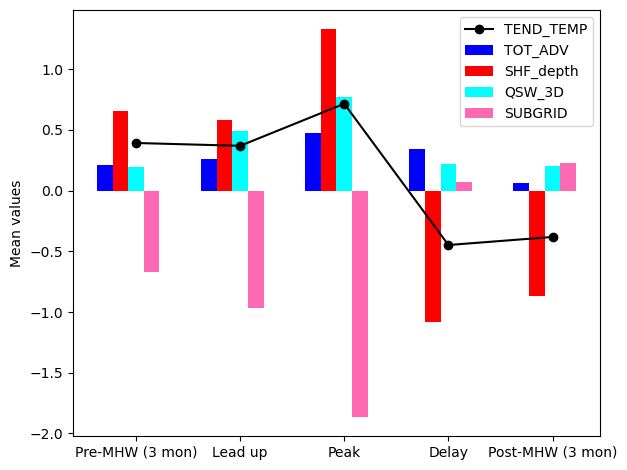

In [239]:
x = np.arange(5)  # Positions for each category

bar_width = 0.15  # Width of each bar
offsets = [-2, -1, 0, 1, 2, 3]  # For staggering the bars around each x

# Plot line
plt.plot(x, TEND_TEMP_result_mn, color='black', label='TEND_TEMP', marker='o')

# Staggered bars
plt.bar(x + bar_width * offsets[0], TOT_ADV_result_mn, width=bar_width, label='TOT_ADV', fc='blue')
plt.bar(x + bar_width * offsets[1], SHF_depth_result_mn, width=bar_width, label='SHF_depth', fc='red')
plt.bar(x + bar_width * offsets[2], QSW_3D_result_mn, width=bar_width, label='QSW_3D', fc='cyan')
plt.bar(x + bar_width * offsets[3], SUBGRID_result_mn, width=bar_width, label='SUBGRID', fc='hotpink')

plt.xticks(x, ['Pre-MHW (3 mon)', 'Lead up', 'Peak', 'Delay', 'Post-MHW (3 mon)'])  # Optional labels
plt.ylabel('Mean values')
plt.legend()
plt.tight_layout()
plt.show()


In [187]:
# fig = plot_tend_temp_segments(TEND_TEMP_result, [0.27, 0.52, -0.04, -0.06], color='k')
# fig = plot_tend_temp_segments(TOT_ADV_result, [0.39, 0.37, 0.38, -1.16], color='blue')
# fig = plot_tend_temp_segments(SHF_depth_result, [0.11, -0.027, -0.07, -0.35], color = 'red')
# fig = plot_tend_temp_segments(QSW_3D_result, [0.46, 0.77, -0.47, -0.95], color = 'lightseagreen')
# fig = plot_tend_temp_segments(SUBGRID_result, [-0.68, -0.61, 0.14, 1.72], color = 'hotpink')

/glade/derecho/scratch/cassiacai/tmp/ipykernel_74611/3094932152.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


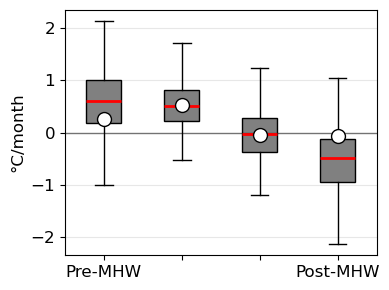

In [20]:
# # Time periods (assuming 4 periods based on your data)
# time_periods = ["Pre-MHW", "", "", "Post-MHW"]  # Adjust if needed
# tend_values = [0.27, 0.52, -0.04, -0.06]  # Values to mark with dots

# plt.figure(figsize=(4, 3))  # Wider to fit all periods

# # Prepare data (filter NaNs for each period)
# all_data = [TEND_TEMP_result[:, i][~np.isnan(TEND_TEMP_result[:, i])] for i in range(4)]

# # Create boxplots (one per period)
# box = plt.boxplot(
#     all_data,
#     patch_artist=True,
#     labels=time_periods,
#     showfliers=False,
#     medianprops={'color': 'red', 'linewidth': 2},
#     positions=range(1, 5)  # Positions 1-4
# )

# # Color all boxes grey (or customize per period)
# for patch in box['boxes']:
#     patch.set_facecolor('grey')

# # Add dots for each period (white with black outline)
# for i, (x_pos, value) in enumerate(zip(range(1, 5), tend_values)):
#     plt.scatter(
#         x_pos,
#         value,
#         color='white',
#         edgecolor='k',
#         s=100,
#         zorder=10,
#         label=f'Value: {value:.2f}°C/month' if i == 0 else ""  # Avoid duplicate labels
#     )

# # Customize plot
# # plt.ylim(-1.5, 1.5)  # Adjusted y-range for better visibility
# plt.axhline(y=0, c='k', linewidth=1, alpha=0.5)
# plt.ylabel('°C/month', fontsize=12)
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
# plt.grid(axis='y', alpha=0.3)  # Optional: light gridlines
# plt.tight_layout()
# plt.show()

In [32]:
fosi_subgrid = [-0.68126979, -0.4523515 , -1.70720718,  2.36915058,  1.72229348]
fosi_shf = [ 0.4608182 ,  0.39687785,  2.06831006, -2.01617492, -0.9516855 ]
fosi_qsw = [ 0.11113862, -0.0278271 , -0.16906707,  0.19347267,  0.34611958]
fosi_tot_adv = [ 0.38970615,  0.40187937,  0.96009357, -1.1134593 , -1.15532734]
fosi_tend_temp = [ 0.27044584,  0.32991785,  1.16578031, -0.5935011 , -0.06119067]

/glade/derecho/scratch/cassiacai/tmp/ipykernel_104168/1082398399.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
/glade/derecho/scratch/cassiacai/tmp/ipykernel_104168/1082398399.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
/glade/derecho/scratch/cassiacai/tmp/ipykernel_104168/1082398399.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
/glade/derecho/scratch/cassiacai/tmp/ipykernel_104168/1082398399.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name w

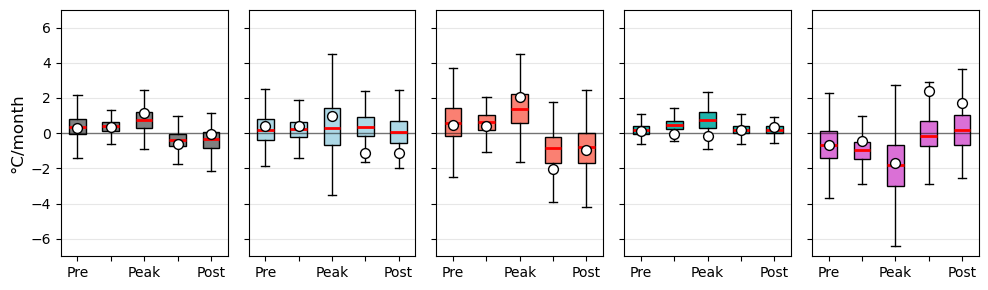

In [36]:
variables = {
    'TEND_TEMP': {'data': np.asarray(TEND_TEMP_result), 'values': fosi_tend_temp, 'color': 'grey'},
    'TOT_ADV': {'data': np.asarray(TOT_ADV_result), 'values': fosi_tot_adv, 'color': 'lightblue'},
    'SHF_depth': {'data': np.asarray(SHF_depth_result), 'values': fosi_shf, 'color': 'salmon'},
    'QSW_3D': {'data': np.asarray(QSW_3D_result), 'values': fosi_qsw, 'color': 'lightseagreen'},
    'SUBGRID': {'data': np.asarray(SUBGRID_result), 'values': fosi_subgrid, 'color': 'orchid'}
}

time_periods = ["Pre", "", "Peak", "", "Post"]

# Create figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 3), sharey=True)

for ax, (var_name, var_data) in zip(axes, variables.items()):
    # Prepare data for all periods
    all_data = [var_data['data'][:, i][~np.isnan(var_data['data'][:, i])] for i in range(5)]
    
    # Create boxplot
    box = ax.boxplot(
        all_data,
        patch_artist=True,
        labels=time_periods,
        showfliers=False,
        medianprops={'color': 'red', 'linewidth': 2},
        positions=range(1, 6)
    )
    
    # Style boxes
    for patch in box['boxes']:
        patch.set_facecolor(var_data['color'])
    
    # Add dots for each period
    for i, (x_pos, value) in enumerate(zip(range(1, 6), var_data['values'])):
        ax.scatter(
            x_pos,
            value,
            color='white',
            edgecolor='k',
            s=50,
            zorder=10,
            label=f'Value: {value:.2f}°C/month' if i == 0 else ""
        )
    
    # Subplot customization
    # ax.set_title(var_name, fontsize=12)
    ax.set_ylim(-7, 7)
    ax.axhline(y=0, c='k', linewidth=1, alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    if ax == axes[0]:
        ax.set_ylabel('°C/month', fontsize=12)
    # ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()